# Accessing ERA5 data from the Earthmover cloud archive

From Earthmover's [Arraylake Marketplace](https://app.earthmover.io/marketplace/6a19bcfe9aa6e97720a2fad2). You need to sign up for a free Earthmover account to access the data. See https://docs.earthmover.io/quickstart.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
from arraylake import Client as alClient

In [2]:
alclient = alClient()

In [3]:
# This step requires a free Earthmover account
alclient.login()

Successfully refreshed tokens! Token stored at /Users/br546577/.arraylake/token.json

╭───────────────────────────────────────────────── User Details ──────────────────────────────────────────────────╮
│ Name: None None                                                                                                 │
│ Email: brose@albany.edu                                                                                         │
│ Id: 42b3a5b8-e618-4e14-aba8-632532f16692                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [4]:
repo = alclient.get_repo("earthmover-public/era5")
session = repo.readonly_session("main")

In [5]:
single_spatial = xr.open_zarr(session.store, group="single/spatial", chunks={})

In [6]:
single_spatial

<xarray.Dataset> Size: 122TB
Dimensions:     (valid_time: 756048, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2026-03-31T23:...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    sdor        (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    lsm         (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    slor        (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    z_sfc       (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
Data variables: (12/39)
    blh         (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    cp          (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    cape        (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    fg10        (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    hcc         (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    fsr         (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    ...          ...
    swvl2       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    zust        (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    u10         (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    u100        (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    tsr         (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    v100        (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes: (12/46)
    Conventions:                CF-1.7
    title:                      ERA5 Hourly Global Reanalysis - chunked for s...
    summary:                    ERA5 is the fifth generation ECMWF atmospheri...
    keywords:                   ERA5, reanalysis, atmosphere, climate, ECMWF,...
    keywords_vocabulary:        GCMD Science Keywords
    id:                         era5
    ...                         ...
    proj:code:                  EPSG:4326
    proj:epsg:                  4326
    GRIB_centre:                ecmf
    GRIB_centreDescription:     European Centre for Medium-Range Weather Fore...
    GRIB_subCentre:             0
    history:                    2026-08-31T08:23 GRIB to CDM+CF via cfgrib-0....

In [7]:
single_spatial.nbytes / 1E12

122.453669658632

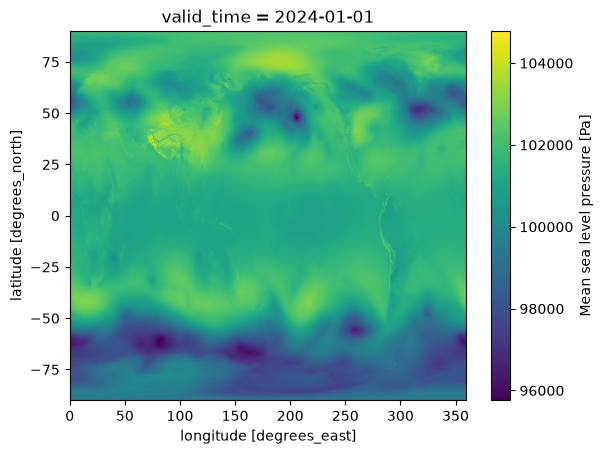

In [8]:
single_spatial.msl.sel(valid_time="2024-01-01T00").plot()

In [9]:
single_temporal = xr.open_zarr(session.store, group="single/temporal", chunks={})

In [10]:
single_temporal

<xarray.Dataset> Size: 122TB
Dimensions:     (valid_time: 756048, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2026-03-31T23:...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    lsm         (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    sdor        (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    slor        (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    z_sfc       (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
Data variables: (12/39)
    cape        (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(8736, 12, 12), meta=np.ndarray>
    blh         (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(8736, 12, 12), meta=np.ndarray>
    fdir        (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(8736, 12, 12), meta=np.ndarray>
    fsr         (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(8736, 12, 12), meta=np.ndarray>
    d2m         (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(8736, 12, 12), meta=np.ndarray>
    fg10        (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(8736, 12, 12), meta=np.ndarray>
    ...          ...
    zust        (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(8736, 12, 12), meta=np.ndarray>
    v10         (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(8736, 12, 12), meta=np.ndarray>
    tsr         (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(8736, 12, 12), meta=np.ndarray>
    v100        (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(8736, 12, 12), meta=np.ndarray>
    u10         (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(8736, 12, 12), meta=np.ndarray>
    tcw         (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(8736, 12, 12), meta=np.ndarray>
Attributes: (12/46)
    Conventions:                CF-1.7
    title:                      ERA5 Hourly Global Reanalysis - chunked for t...
    summary:                    ERA5 is the fifth generation ECMWF atmospheri...
    keywords:                   ERA5, reanalysis, atmosphere, climate, ECMWF,...
    keywords_vocabulary:        GCMD Science Keywords
    id:                         era5
    ...                         ...
    proj:code:                  EPSG:4326
    proj:epsg:                  4326
    GRIB_centre:                ecmf
    GRIB_centreDescription:     European Centre for Medium-Range Weather Fore...
    GRIB_subCentre:             0
    history:                    2026-08-31T08:23 GRIB to CDM+CF via cfgrib-0....

## Pressure-level data

In [11]:
pressure_temporal = xr.open_zarr(session.store, group="pressure/temporal", chunks={})

In [12]:
pressure_temporal

<xarray.Dataset> Size: 327TB
Dimensions:         (valid_time: 756048, pressure_level: 13, latitude: 721,
                     longitude: 1440)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2026-03-31...
  * pressure_level  (pressure_level) float64 104B 1e+03 925.0 ... 100.0 50.0
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    lsm             (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    sdor            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    slor            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    z_sfc           (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
Data variables:
    r               (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(8736, 1, 12, 12), meta=np.ndarray>
    pv              (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(8736, 1, 12, 12), meta=np.ndarray>
    u               (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(8736, 1, 12, 12), meta=np.ndarray>
    q               (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(8736, 1, 12, 12), meta=np.ndarray>
    t               (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(8736, 1, 12, 12), meta=np.ndarray>
    v               (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(8736, 1, 12, 12), meta=np.ndarray>
    w               (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(8736, 1, 12, 12), meta=np.ndarray>
    z               (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(8736, 1, 12, 12), meta=np.ndarray>
Attributes: (12/46)
    Conventions:                CF-1.7
    title:                      ERA5 Hourly Global Reanalysis - chunked for t...
    summary:                    ERA5 is the fifth generation ECMWF atmospheri...
    keywords:                   ERA5, reanalysis, atmosphere, climate, ECMWF,...
    keywords_vocabulary:        GCMD Science Keywords
    id:                         era5
    ...                         ...
    proj:code:                  EPSG:4326
    proj:epsg:                  4326
    GRIB_centre:                ecmf
    GRIB_centreDescription:     European Centre for Medium-Range Weather Fore...
    GRIB_subCentre:             0
    history:                    2026-05-05T13:36 GRIB to CDM+CF via cfgrib-0....

In [13]:
pressure_temporal.nbytes / 1E12

326.543081293936

In [14]:
pressure_temporal.pressure_level

<xarray.DataArray 'pressure_level' (pressure_level: 13)> Size: 104B
array([1000.,  925.,  850.,  700.,  600.,  500.,  400.,  300.,  250.,  200.,
        150.,  100.,   50.])
Coordinates:
  * pressure_level  (pressure_level) float64 104B 1e+03 925.0 ... 100.0 50.0
Attributes:
    long_name:         pressure
    units:             hPa
    positive:          down
    stored_direction:  decreasing
    standard_name:     air_pressure
    axis:              Z

In [15]:
pressure_temporal.t

<xarray.DataArray 't' (valid_time: 756048, pressure_level: 13, latitude: 721,
                       longitude: 1440)> Size: 41TB
dask.array<open_dataset-t, shape=(756048, 13, 721, 1440), dtype=float32, chunksize=(8736, 1, 12, 12), chunktype=numpy.ndarray>
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2026-03-31...
  * pressure_level  (pressure_level) float64 104B 1e+03 925.0 ... 100.0 50.0
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    lsm             (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    sdor            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    slor            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    z_sfc           (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
Attributes: (12/31)
    GRIB_paramId:                             130
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           t
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                Temperature
    units:                                    K
    standard_name:                            air_temperature

## A derived quadratic field

Compute the product $v T$

In [16]:
vT_temporal = pressure_temporal.v * pressure_temporal.t
vT_temporal

<xarray.DataArray (valid_time: 756048, pressure_level: 13, latitude: 721,
                   longitude: 1440)> Size: 41TB
dask.array<mul, shape=(756048, 13, 721, 1440), dtype=float32, chunksize=(8736, 1, 12, 12), chunktype=numpy.ndarray>
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2026-03-31...
  * pressure_level  (pressure_level) float64 104B 1e+03 925.0 ... 100.0 50.0
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    lsm             (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    sdor            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    slor            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    z_sfc           (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
Attributes: (12/22)
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_latitudeOfFirstGridPointInDegrees:   90.0
    GRIB_latitudeOfLastGridPointInDegrees:    -90.0
    GRIB_longitudeOfFirstGridPointInDegrees:  0.0
    GRIB_longitudeOfLastGridPointInDegrees:   359.75
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_totalNumber:                         0

In [17]:
pressure_spatial = xr.open_zarr(session.store, group="pressure/spatial", chunks={})

In [18]:
vT_spatial = pressure_spatial.v * pressure_spatial.t
vT_spatial

<xarray.DataArray (valid_time: 756048, pressure_level: 13, latitude: 721,
                   longitude: 1440)> Size: 41TB
dask.array<mul, shape=(756048, 13, 721, 1440), dtype=float32, chunksize=(1, 1, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2026-03-31...
  * pressure_level  (pressure_level) float64 104B 1e+03 925.0 ... 100.0 50.0
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    lsm             (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    slor            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    sdor            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    z_sfc           (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
Attributes: (12/22)
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_latitudeOfFirstGridPointInDegrees:   90.0
    GRIB_latitudeOfLastGridPointInDegrees:    -90.0
    GRIB_longitudeOfFirstGridPointInDegrees:  0.0
    GRIB_longitudeOfLastGridPointInDegrees:   359.75
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_totalNumber:                         0

In [19]:
vT_spatial.sel(pressure_level = 500.)

<xarray.DataArray (valid_time: 756048, latitude: 721, longitude: 1440)> Size: 3TB
dask.array<getitem, shape=(756048, 721, 1440), dtype=float32, chunksize=(1, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2026-03-31...
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    lsm             (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    slor            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    sdor            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    z_sfc           (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    pressure_level  float64 8B 500.0
Attributes: (12/22)
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_latitudeOfFirstGridPointInDegrees:   90.0
    GRIB_latitudeOfLastGridPointInDegrees:    -90.0
    GRIB_longitudeOfFirstGridPointInDegrees:  0.0
    GRIB_longitudeOfLastGridPointInDegrees:   359.75
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_totalNumber:                         0

In [20]:
vT_spatial.sel(pressure_level = 500., valid_time="2024-01-01T00")

<xarray.DataArray (latitude: 721, longitude: 1440)> Size: 4MB
dask.array<getitem, shape=(721, 1440), dtype=float32, chunksize=(721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    lsm             (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    slor            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    sdor            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    z_sfc           (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    pressure_level  float64 8B 500.0
    valid_time      datetime64[ns] 8B 2024-01-01
Attributes: (12/22)
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_latitudeOfFirstGridPointInDegrees:   90.0
    GRIB_latitudeOfLastGridPointInDegrees:    -90.0
    GRIB_longitudeOfFirstGridPointInDegrees:  0.0
    GRIB_longitudeOfLastGridPointInDegrees:   359.75
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_totalNumber:                         0